<a href="https://colab.research.google.com/github/HM-Mahibullah/ComputerVision/blob/main/Labproblem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: M/M/1

In [3]:
# Lab 01: M/M/1 Queue Simulation
import random
import math

def exponential(mean):
    return -mean * math.log(random.random())

def mm1_simulation(mean_interarrival, mean_service, max_customers):
    clock = 0.0
    num_in_queue = 0
    server_busy = False
    next_arrival = exponential(mean_interarrival)
    next_departure = float('inf')

    total_delay = 0.0
    total_queue = 0.0
    last_event_time = 0.0
    server_busy_time = 0.0
    customers_served = 0
    arrival_times = []

    while customers_served < max_customers:
        if next_arrival < next_departure:
            prev_time = clock
            clock = next_arrival
            total_queue += num_in_queue * (clock - last_event_time)
            if server_busy:
                num_in_queue += 1
                server_busy_time += (clock - prev_time) if clock > prev_time else 0
            else:
                server_busy = True
                delay = 0.0
                total_delay += delay
                customers_served += 1
                next_departure = clock + exponential(mean_service)
            arrival_times.append(clock)
            next_arrival = clock + exponential(mean_interarrival)
            last_event_time = clock
        else:
            prev_time = clock
            clock = next_departure
            total_queue += num_in_queue * (clock - last_event_time)
            server_busy_time += (clock - prev_time)
            if num_in_queue > 0:
                num_in_queue -= 1
                delay = clock - arrival_times[customers_served - num_in_queue - 1] if arrival_times else 0
                total_delay += max(0, delay)
                customers_served += 1
                next_departure = clock + exponential(mean_service)
            else:
                server_busy = False
                next_departure = float('inf')
            last_event_time = clock

    avg_delay = total_delay / max_customers
    avg_queue = total_queue / clock
    utilization = server_busy_time / clock

    print("=" * 50)
    print("   M/M/1 Queue Simulation")
    print("=" * 50)
    print(f"Mean Inter-arrival Time : {mean_interarrival} min")
    print(f"Mean Service Time       : {mean_service} min")
    print(f"Max Customers           : {max_customers}")
    print("-" * 50)
    print(f"Average Delay in Queue  : {avg_delay:.4f} min")
    print(f"Average Number in Queue : {avg_queue:.4f}")
    print(f"Server Utilization      : {utilization:.4f} ({utilization*100:.2f}%)")
    print(f"Simulation End Time     : {clock:.4f} min")
    print("=" * 50)

random.seed(42)
mm1_simulation(mean_interarrival=2.0, mean_service=1.5, max_customers=1000)

   M/M/1 Queue Simulation
Mean Inter-arrival Time : 2.0 min
Mean Service Time       : 1.5 min
Max Customers           : 1000
--------------------------------------------------
Average Delay in Queue  : 9.5113 min
Average Number in Queue : 2.4172
Server Utilization      : 0.7775 (77.75%)
Simulation End Time     : 1907.6781 min


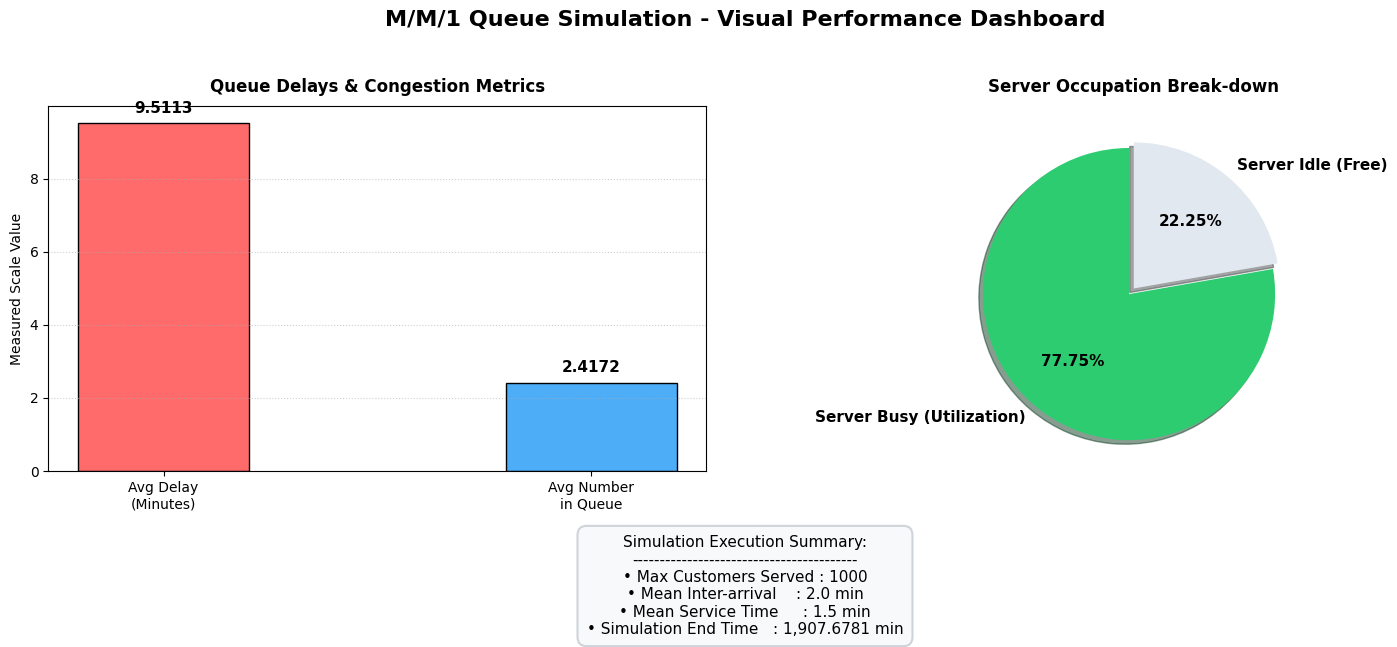

In [4]:
import matplotlib.pyplot as plt
import numpy as np


mean_interarrival = 2.0
mean_service = 1.5
max_customers = 1000
avg_delay = 9.5113
avg_queue = 2.4172
utilization = 0.7775
end_time = 1907.6781


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('M/M/1 Queue Simulation - Visual Performance Dashboard', fontsize=16, fontweight='bold', y=0.98)


labels = ['Avg Delay\n(Minutes)', 'Avg Number\nin Queue']
values = [avg_delay, avg_queue]
colors = ['#ff6b6b', '#4dadf7']

bars = ax1.bar(labels, values, color=colors, edgecolor='black', width=0.4)


for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.2, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax1.set_title('Queue Delays & Congestion Metrics', fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel('Measured Scale Value', fontsize=10)
ax1.grid(axis='y', linestyle=':', alpha=0.6)

util_labels = ['Server Busy (Utilization)', 'Server Idle (Free)']
util_sizes = [utilization * 100, (1 - utilization) * 100]
util_colors = ['#2ecc71', '#e2e8f0']

ax2.pie(util_sizes, labels=util_labels, autopct='%1.2f%%', startangle=90,
        colors=util_colors, explode=(0.05, 0), shadow=True, textprops={'fontweight': 'bold', 'fontsize': 11})

ax2.set_title('Server Occupation Break-down', fontsize=12, fontweight='bold', pad=10)

info_text = (
    f"Simulation Execution Summary:\n"
    f"-----------------------------------------\n"
    f"• Max Customers Served : {max_customers}\n"
    f"• Mean Inter-arrival    : {mean_interarrival} min\n"
    f"• Mean Service Time     : {mean_service} min\n"
    f"• Simulation End Time   : {end_time:,.4f} min"
)
fig.text(0.5, 0.02, info_text, ha='center', va='center', fontsize=11, fontweight='500',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', edgecolor='#ced4da', lw=1.5))

plt.tight_layout(rect=[0, 0.12, 1, 0.95])
plt.show()

# Lab 2 :

        Lab 02: Inventory Management Simulation
Day   Demand    Stock     Order     Status
------------------------------------------------------------
1     10        90                  OK
2     8         82                  OK
3     13        69                  OK
4     9         60                  OK
5     7         53                  OK
6     11        42                  OK
7     6         36                  OK
8     15        21                  OK
9     9         12        ORDER     OK
10    13        0                   SHORTAGE:1
50    11        1                   OK
100   5         45                  OK
150   8         24                  OK
200   12        0                   SHORTAGE:9
250   10        32                  OK
300   4         17        ORDER     OK
350   16        34                  OK
------------------------------------------------------------

Total Holding Cost  : $12708.00
Total Shortage Cost : $7670.00
Total Order Cost    : $2650.00
Total Cost   

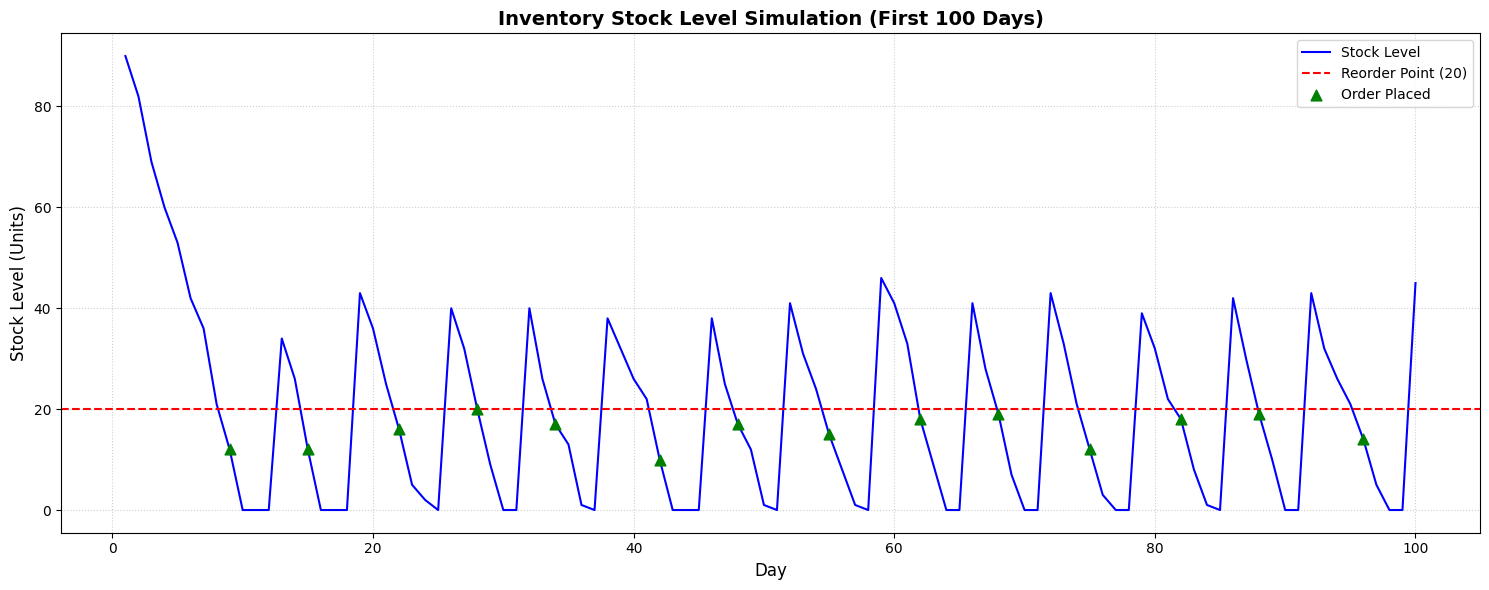

In [5]:
import random
import matplotlib.pyplot as plt

def inventory_simulation(initial_stock=100, reorder_point=20, reorder_qty=50,
                         days=365, mean_demand=10, order_cost=50,
                         holding_cost=2, shortage_cost=10):
    stock = initial_stock
    total_holding = 0
    total_shortage = 0
    total_order_cost = 0
    orders_placed = 0
    pending_order = False
    pending_days = 0

    # --- গ্রাফের ডেটা সংরক্ষণের জন্য লিস্ট (Lists for Graphing) ---
    day_history = []
    stock_history = []
    order_days = []
    order_stock_levels = []

    print("=" * 60)
    print("        Lab 02: Inventory Management Simulation")
    print("=" * 60)
    print(f"{'Day':<6}{'Demand':<10}{'Stock':<10}{'Order':<10}{'Status'}")
    print("-" * 60)

    for day in range(1, days + 1):
        demand = max(0, int(random.normalvariate(mean_demand, 3)))

        if pending_order and pending_days <= 0:
            stock += reorder_qty
            pending_order = False

        if pending_order:
            pending_days -= 1

        if stock >= demand:
            stock -= demand
            status = "OK"
        else:
            shortage = demand - stock
            total_shortage += shortage * shortage_cost
            stock = 0
            status = f"SHORTAGE:{shortage}"

        total_holding += stock * holding_cost

        order_placed = ""
        if stock <= reorder_point and not pending_order:
            pending_order = True
            pending_days = 3
            total_order_cost += order_cost
            orders_placed += 1
            order_placed = "ORDER"


            order_days.append(day)
            order_stock_levels.append(stock)


        day_history.append(day)
        stock_history.append(stock)

        if day <= 10 or day % 50 == 0:
            print(f"{day:<6}{demand:<10}{stock:<10}{order_placed:<10}{status}")

    total_cost = total_holding + total_shortage + total_order_cost
    print("-" * 60)
    print(f"\nTotal Holding Cost  : ${total_holding:.2f}")
    print(f"Total Shortage Cost : ${total_shortage:.2f}")
    print(f"Total Order Cost    : ${total_order_cost:.2f}")
    print(f"Total Cost          : ${total_cost:.2f}")
    print(f"Orders Placed       : {orders_placed}")
    print("=" * 60)

    plt.figure(figsize=(15, 6))

    plt.plot(day_history[:100], stock_history[:100], label='Stock Level', color='blue', linewidth=1.5)

    plt.axhline(y=reorder_point, color='red', linestyle='--', label=f'Reorder Point ({reorder_point})')


    filtered_order_days = [d for d in order_days if d <= 100]
    filtered_order_stocks = [order_stock_levels[i] for i, d in enumerate(order_days) if d <= 100]
    plt.scatter(filtered_order_days, filtered_order_stocks, color='green', marker='^', s=60, label='Order Placed', zorder=5)


    plt.title('Inventory Stock Level Simulation (First 100 Days)', fontsize=14, fontweight='bold')
    plt.xlabel('Day', fontsize=12)
    plt.ylabel('Stock Level (Units)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)


    plt.tight_layout()
    plt.show()


random.seed(42)
inventory_simulation()

# Lab-3

   Lab 03: Continuous Review Inventory Simulation
Reorder Point (s) = 30, Max Stock (S) = 100
Mean Demand = 15, Std = 5
------------------------------------------------------------
Simulation Period   : 365 days
Total Holding Cost  : $29657.19
Total Shortage Cost : $0.00
Total Order Cost    : $5175.00
Total Cost          : $34832.19
Total Orders Placed : 69


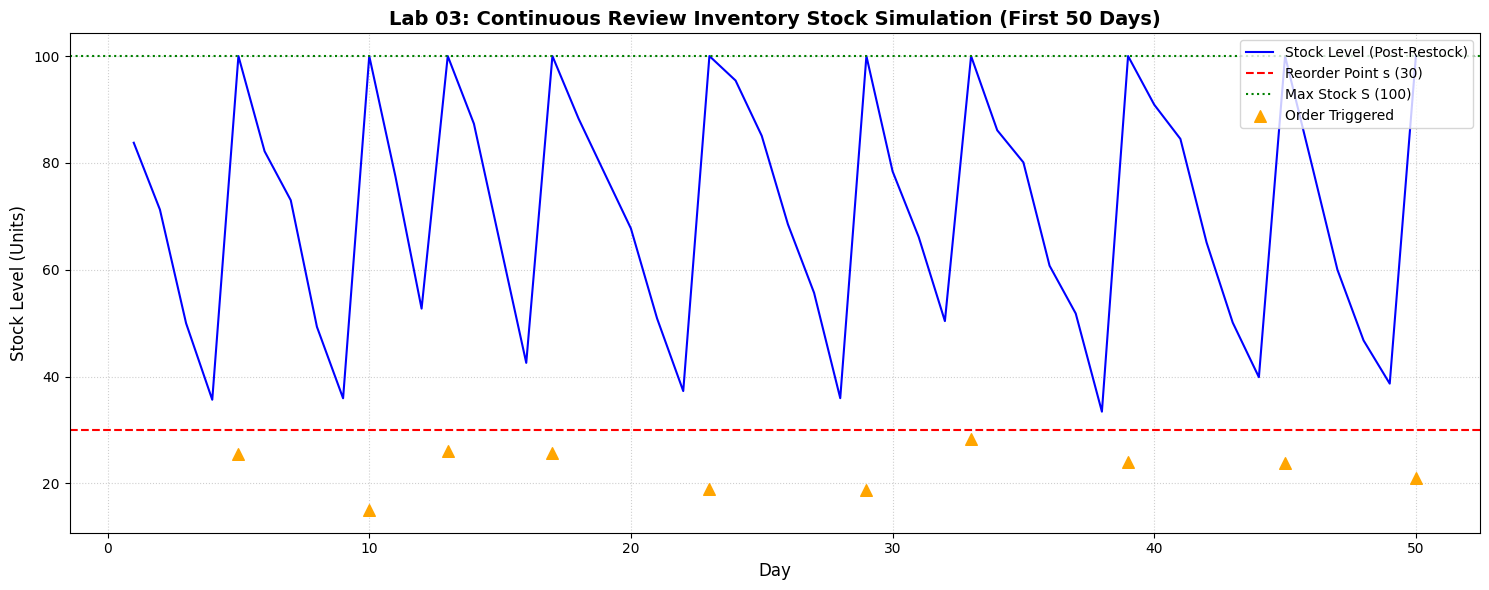

In [6]:
import random
import matplotlib.pyplot as plt

def continuous_review_simulation(s=30, S=100, days=365, mean_demand=15,
                                   std_demand=5, holding_cost=1.5,
                                   shortage_cost=20, order_cost=75):
    stock = S
    total_holding = 0
    total_shortage = 0
    total_order_cost = 0
    orders = 0

    day_history = []
    stock_history = []
    order_days = []
    order_stock_levels = []

    print("=" * 60)
    print("   Lab 03: Continuous Review Inventory Simulation")
    print("=" * 60)
    print(f"Reorder Point (s) = {s}, Max Stock (S) = {S}")
    print(f"Mean Demand = {mean_demand}, Std = {std_demand}")
    print("-" * 60)

    for day in range(1, days + 1):
        demand = max(0, random.normalvariate(mean_demand, std_demand))

        if stock >= demand:
            stock -= demand
        else:
            shortage = demand - stock
            total_shortage += shortage * shortage_cost
            stock = 0

        total_holding += stock * holding_cost

        if stock <= s:
            qty = S - stock

            order_days.append(day)
            order_stock_levels.append(stock)

            stock += qty
            total_order_cost += order_cost
            orders += 1

        day_history.append(day)
        stock_history.append(stock)

    total_cost = total_holding + total_shortage + total_order_cost
    print(f"Simulation Period   : {days} days")
    print(f"Total Holding Cost  : ${total_holding:.2f}")
    print(f"Total Shortage Cost : ${total_shortage:.2f}")
    print(f"Total Order Cost    : ${total_order_cost:.2f}")
    print(f"Total Cost          : ${total_cost:.2f}")
    print(f"Total Orders Placed : {orders}")
    print("=" * 60)

    plt.figure(figsize=(15, 6))

    plt.plot(day_history[:50], stock_history[:50], label='Stock Level (Post-Restock)', color='blue', linewidth=1.5)
    plt.axhline(y=s, color='red', linestyle='--', label=f'Reorder Point s ({s})')
    plt.axhline(y=S, color='green', linestyle=':', label=f'Max Stock S ({S})')

    filtered_order_days = [d for d in order_days if d <= 50]
    filtered_order_stocks = [order_stock_levels[i] for i, d in enumerate(order_days) if d <= 50]
    plt.scatter(filtered_order_days, filtered_order_stocks, color='orange', marker='^', s=70, label='Order Triggered', zorder=5)

    plt.title('Lab 03: Continuous Review Inventory Stock Simulation (First 50 Days)', fontsize=14, fontweight='bold')
    plt.xlabel('Day', fontsize=12)
    plt.ylabel('Stock Level (Units)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

random.seed(42)
continuous_review_simulation()

# Lab-4 : # Lab 04: Bernoulli Distribution - Microchip Quality Control
$$P(X = 1) = p$$$$P(X = 0) = 1 - p = q$$

   Lab 04: Bernoulli Distribution Simulation
Success Probability p = 0.85
Failure Probability q = 0.15000000000000002
-------------------------------------------------------

--- Theoretical Values ---
P(X=1) Pass = 0.85
P(X=0) Fail = 0.15
E[X] Mean   = 0.85
Var(X)      = 0.1275

--- Simulation Results (n=1000) ---
Chips Passed  : 837 (83.7%)
Chips Failed  : 163 (16.3%)
Simulated Mean: 0.8370
Theoretical Mean: 0.8500


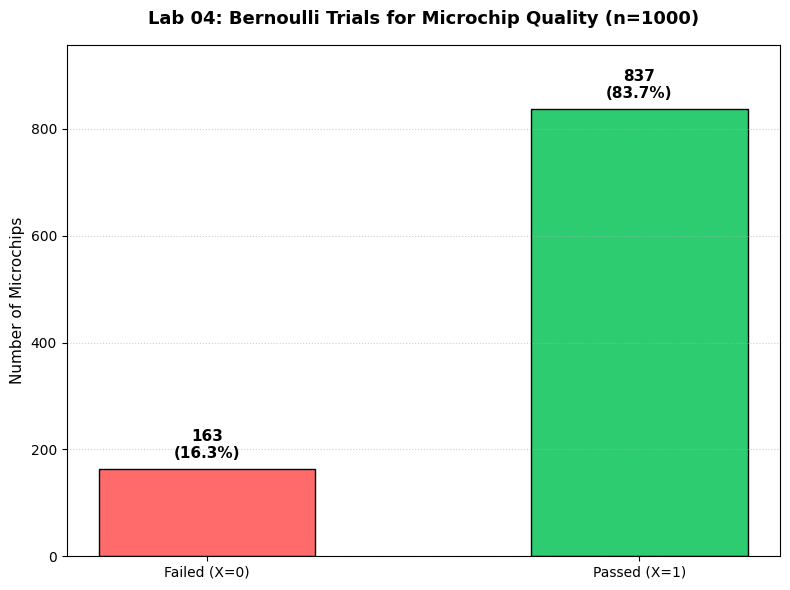

In [7]:
import random
import matplotlib.pyplot as plt

def bernoulli_simulation(p=0.85, n=1000):
    print("=" * 55)
    print("   Lab 04: Bernoulli Distribution Simulation")
    print("=" * 55)
    print(f"Success Probability p = {p}")
    print(f"Failure Probability q = {1-p}")
    print("-" * 55)

    q = 1 - p
    E_X = p
    Var_X = p * q

    print(f"\n--- Theoretical Values ---")
    print(f"P(X=1) Pass = {p}")
    print(f"P(X=0) Fail = {q:.2f}")
    print(f"E[X] Mean   = {E_X}")
    print(f"Var(X)      = {Var_X:.4f}")

    results = [1 if random.random() < p else 0 for _ in range(n)]
    sim_mean = sum(results) / n
    sim_pass = results.count(1)
    sim_fail = results.count(0)

    print(f"\n--- Simulation Results (n={n}) ---")
    print(f"Chips Passed  : {sim_pass} ({sim_pass/n*100:.1f}%)")
    print(f"Chips Failed  : {sim_fail} ({sim_fail/n*100:.1f}%)")
    print(f"Simulated Mean: {sim_mean:.4f}")
    print(f"Theoretical Mean: {E_X:.4f}")
    print("=" * 55)

    plt.figure(figsize=(8, 6))

    categories = ['Failed (X=0)', 'Passed (X=1)']
    counts = [sim_fail, sim_pass]
    colors = ['#ff6b6b', '#2ecc71']

    bars = plt.bar(categories, counts, color=colors, edgecolor='black', width=0.5)

    for bar in bars:
        height = bar.get_height()
        percentage = (height / n) * 100
        plt.text(bar.get_x() + bar.get_width()/2.0, height + 15,
                 f'{height}\n({percentage:.1f}%)',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

    plt.title(f'Lab 04: Bernoulli Trials for Microchip Quality (n={n})', fontsize=13, fontweight='bold', pad=15)
    plt.ylabel('Number of Microchips', fontsize=11)
    plt.ylim(0, max(counts) + 120)
    plt.grid(axis='y', linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

random.seed(42)
bernoulli_simulation()

# Lab 05: Network Packet Delivery - Binomial Distribution

একটি সাধারণ ছয়-পার্শ্বযুক্ত ছক্কা গড়ানোর কথা কল্পনা করুন। ধরা যাক \(X\) , আপনি যে সংখ্যাটি গড়িয়েছেন তা হলো দৈব চলক। নমুনা ক্ষেত্রটি হলো \(\{1, 2, 3, 4, 5, 6\}\)।PMF অনুযায়ী, যেকোনো নির্দিষ্ট সংখ্যা পাওয়ার সম্ভাবনা হলো \(\frac{1}{6}\):

   Lab 05: Network Packet Delivery (Binomial)
Parameters: n=15, p=0.9, q=0.09999999999999998
-------------------------------------------------------
P(X=13) exactly 13 packets : 0.266896

Theoretical Mean μ         : 13.50
Theoretical Variance σ²    : 1.3500
Std Deviation σ            : 1.1619

Example Data               : [14, 13, 15, 12, 14]
Sample Average             : 13.60
Theoretical Mean           : 13.50
Difference                 : 0.10


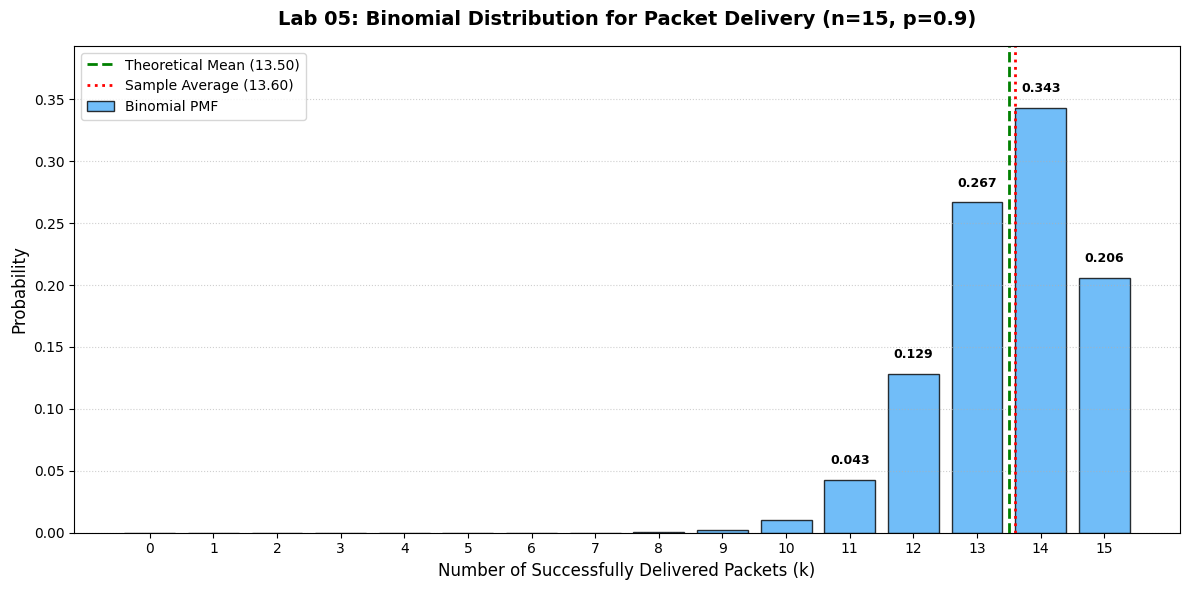

In [8]:
import math
import matplotlib.pyplot as plt

def binomial_prob(n, k, p):
    comb = math.comb(n, k)
    return comb * (p**k) * ((1-p)**(n-k))

def network_simulation():
    n = 15
    p = 0.90
    q = 1 - p
    k = 13
    data = [14, 13, 15, 12, 14]

    print("=" * 55)
    print("   Lab 05: Network Packet Delivery (Binomial)")
    print("=" * 55)
    print(f"Parameters: n={n}, p={p}, q={q}")
    print("-" * 55)

    prob_13 = binomial_prob(n, k, p)
    mean = n * p
    variance = n * p * q
    std = math.sqrt(variance)
    data_avg = sum(data) / len(data)

    print(f"P(X=13) exactly 13 packets : {prob_13:.6f}")
    print(f"\nTheoretical Mean μ         : {mean:.2f}")
    print(f"Theoretical Variance σ²    : {variance:.4f}")
    print(f"Std Deviation σ            : {std:.4f}")
    print(f"\nExample Data               : {data}")
    print(f"Sample Average             : {data_avg:.2f}")
    print(f"Theoretical Mean           : {mean:.2f}")
    print(f"Difference                 : {abs(data_avg - mean):.2f}")
    print("=" * 55)

    x_values = list(range(n + 1))
    probabilities = [binomial_prob(n, x, p) for x in x_values]

    plt.figure(figsize=(12, 6))

    bars = plt.bar(x_values, probabilities, color='#4dadf7', edgecolor='black', alpha=0.8, label='Binomial PMF')

    for i, bar in enumerate(bars):
        if i >= 11:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01,
                     f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.axvline(x=mean, color='green', linestyle='--', linewidth=2, label=f'Theoretical Mean ({mean:.2f})')
    plt.axvline(x=data_avg, color='red', linestyle=':', linewidth=2, label=f'Sample Average ({data_avg:.2f})')

    plt.title(f'Lab 05: Binomial Distribution for Packet Delivery (n={n}, p={p})', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Number of Successfully Delivered Packets (k)', fontsize=12)
    plt.ylabel('Probability', fontsize=12)
    plt.xticks(x_values)
    plt.ylim(0, max(probabilities) + 0.05)
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

network_simulation()